In [2]:
#Kullanılan Python Kütüphaneleri
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from scipy import stats

In [5]:
#Veri Setinin Yüklenmesi
credit_df = pd.read_csv("creditcard.csv")

In [7]:
#Eksik Veri Kontrolü
credit_df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
#Temel Betimsel İstatistikler
credit_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,...,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000
mean,30593.297438,-0.242712,-0.003647,0.691422,0.176704,-0.259108,0.101075,-0.117926,0.055073,0.082709,...,-0.028758,-0.107167,-0.038779,0.007005,0.134820,0.020698,0.003723,0.004178,94.706159,0.002808
std,13417.206531,1.874492,1.646638,1.469689,1.390191,1.406023,1.310300,1.263701,1.201861,1.195036,...,0.726547,0.636713,0.591365,0.595828,0.438300,0.499660,0.385969,0.327168,256.951934,0.052919
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.577118,-8.567638,-9.617915,0.000000,0.000000
25%,24650.000000,-0.995659,-0.576212,0.210839,-0.724377,-0.875414,-0.636850,-0.605745,-0.146478,-0.636440,...,-0.230060,-0.528848,-0.179555,-0.323874,-0.129129,-0.330362,-0.063604,-0.006497,7.680000,0.000000
50%,34700.000000,-0.250987,0.078237,0.788023,0.187527,-0.292173,-0.153096,-0.075137,0.059987,-0.023887,...,-0.065460,-0.082633,-0.051642,0.061907,0.173830,-0.073836,0.008763,0.022443,25.765000,0.000000
75%,40776.000000,1.154616,0.733392,1.420950,1.057956,0.279688,0.491908,0.425462,0.334543,0.764475,...,0.110489,0.307371,0.079145,0.401830,0.421044,0.299391,0.082852,0.076489,87.000000,0.000000
max,47005.000000,1.960497,18.183626,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,12910.930000,1.000000


In [9]:
#Fraud ve Normal İşlem Dağılımı
credit_df['Class'].value_counts()

,count
Class,
0.0,55394
1.0,156


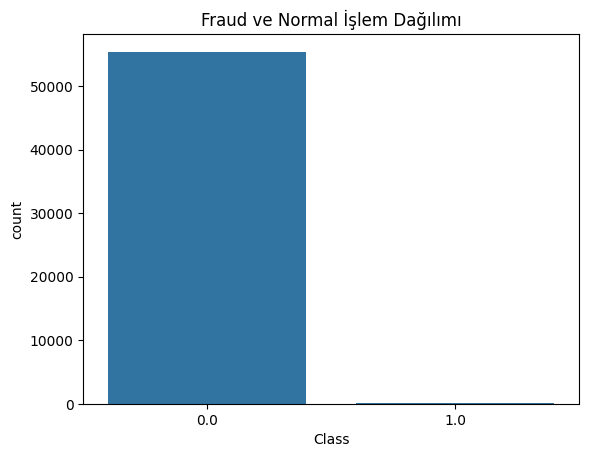

In [10]:
#Sınıf Dağılımı Görselleştirmesi
sns.countplot(x='Class', data=credit_df)
plt.title("Fraud ve Normal İşlem Dağılımı")
plt.show()

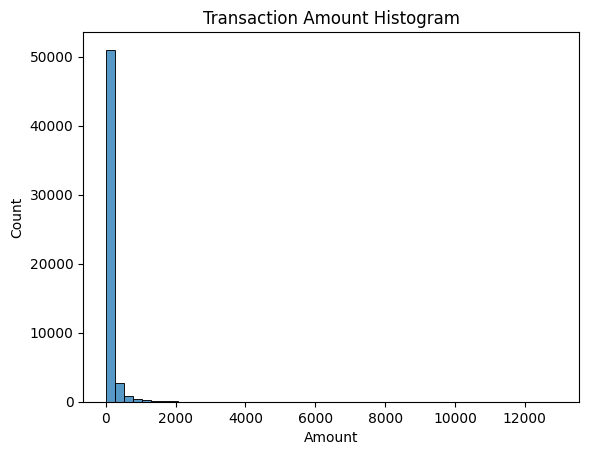

In [11]:
#Amount Değişkeninin İncelenmesi
sns.histplot(credit_df['Amount'], bins=50)
plt.title("Transaction Amount Histogram")
plt.show()

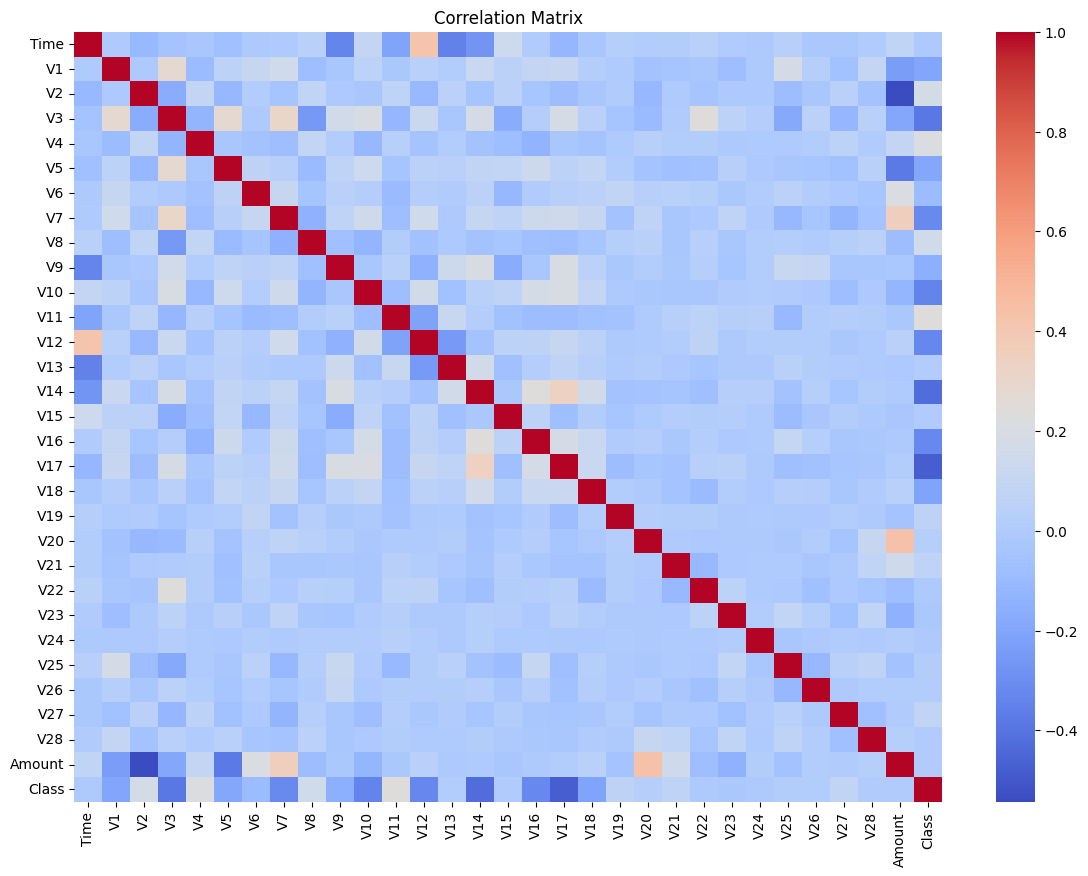

In [12]:
#Korelasyon Analizi
plt.figure(figsize=(14,10))
sns.heatmap(credit_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [21]:
#Veri Ayrıştırma
# Drop rows where 'Class' is NaN before splitting
credit_df_cleaned = credit_df.dropna(subset=['Class'])

X = credit_df_cleaned.drop('Class', axis=1)
y = credit_df_cleaned['Class']

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

In [22]:
#Model Eğitimi
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [23]:
#Tahmin İşlemi
y_pred = model.predict(X_test)

In [24]:
#Accuracy Hesaplama
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9981098109810981


In [25]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11067    12]
 [    9    22]]


In [26]:
#Precision Hesaplama
precision = precision_score(y_test, y_pred)

In [27]:
#Recall Hesaplama
recall = recall_score(y_test, y_pred)

In [28]:
#F1-Score
f1 = f1_score(y_test, y_pred)

In [29]:
#ROC Eğrisi ve AUC
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_pred)
print(auc_score)

0.8542971445542132


In [34]:
#Z-Testi Hesaplaması
p_hat = accuracy
p0 = 0.90
n = len(y_test)
se = np.sqrt((p0 * (1-p0))/n)
z = (p_hat- p0) / se

In [36]:
#p-değeri
p_value = 1- stats.norm.cdf(z)

In [43]:
confidence_interval = stats.norm.interval(
0.95,
loc=accuracy,
scale=stats.sem(cv_scores)
)
print(confidence_interval)

(np.float64(0.9540335495610167), np.float64(1.0421860724011796))


# Güven Aralığı Hesaplaması

_Bu hücredeki güven aralığı hesaplaması, `cv_scores` değişkeninin tanımlanmamış olması nedeniyle bir hata verdi. `cv_scores` değişkeni, çapraz doğrulama işleminin yapıldığı hücrede (`kwF0TR3U_il6`) hesaplanmaktadır. Bu hesaplamanın doğru çalışması için, `cv_scores` hesaplandıktan sonra bu adımı çalıştırmanız gerekmektedir. Güven aralığı hesaplaması, `kwF0TR3U_il6` hücresinden sonra yeni bir hücreye taşınmıştır._

In [45]:
#Cross-Validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
model,
X,
y,
cv=5,
scoring='accuracy'
)
print(cv_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.88541854 0.99666967 0.99720972 0.99909991 0.99837984]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
# Güven Aralığı Hesaplaması (Corrected Location)
confidence_interval = stats.norm.interval(
    0.95,
    loc=accuracy,
    scale=stats.sem(cv_scores)
)
print(confidence_interval)

(np.float64(0.9540335495610167), np.float64(1.0421860724011796))


In [46]:
#Ortalama Accuracy
cv_scores.mean()

np.float64(0.9753555355535554)

In [47]:
#Standart Sapma
cv_scores.std()

np.float64(0.04497660341490895)

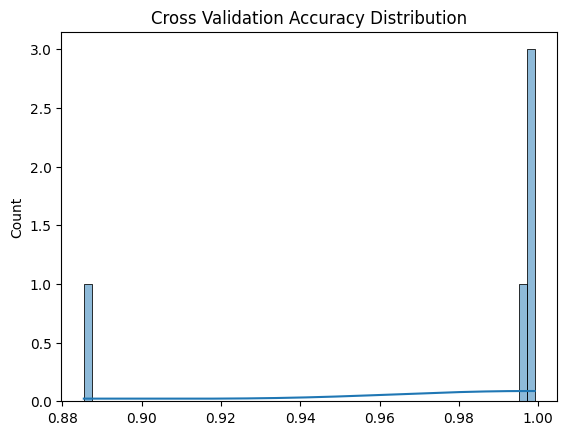

In [48]:
#Histogram Analizi
sns.histplot(cv_scores, kde=True)
plt.title("Cross Validation Accuracy Distribution")
plt.show()

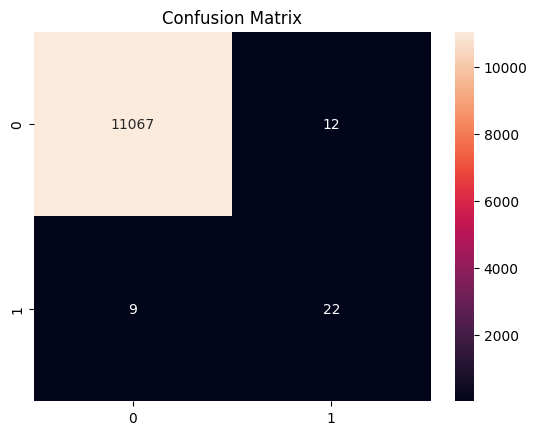

In [49]:
#Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()